In [56]:
import pandas as pd
import missingno as msno
import numpy as np
from thefuzz import process
import matplotlib.pyplot as plt

In [57]:
Turnover = pd.read_csv('./Employee Turnover Dataset.csv')
Turnover.columns = Turnover.columns.str.replace(' ','',regex=False)

In [58]:
# Finding Duplicate Records
duplicate_recs = Turnover[Turnover.duplicated(keep=False)]
duplicate_recs.sort_values(by='EmployeeNumber',inplace=True)
duplicate_recs

C:\Users\tyler\AppData\Local\Temp\ipykernel_15192\3150353371.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplicate_recs.sort_values(by='EmployeeNumber',inplace=True)


,EmployeeNumber,Age,Tenure,Turnover,HourlyRate,HoursWeekly,CompensationType,AnnualSalary,DrivingCommuterDistance,JobRoleArea,Gender,MaritalStatus,NumCompaniesPreviouslyWorked,AnnualProfessionalDevHrs,PaycheckMethod,TextMessageOptIn
0,1,28,6,Yes,$24.37,40,Salary,50689.6,89,Research,Female,Married,3.0,7.0,Mail Check,Yes
10100,1,28,6,Yes,$24.37,40,Salary,50689.6,89,Research,Female,Married,3.0,7.0,Mail Check,Yes
1,2,33,2,Yes,$24.37,40,Salary,50689.6,89,Research,Female,Married,6.0,7.0,Mail Check,Yes
10101,2,33,2,Yes,$24.37,40,Salary,50689.6,89,Research,Female,Married,6.0,7.0,Mail Check,Yes
2,3,22,1,No,$22.52,40,Salary,46841.6,35,Information_Technology,Female,Single,1.0,8.0,Mailed Check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,97,44,6,No,$71.90,40,Salary,149552.0,32,Marketing,Male,Married,6.0,NaN,Mail Check,Yes
10197,98,58,19,No,$71.90,40,Salary,149552.0,32,Marketing,Male,Married,5.0,23.0,Mail Check,Yes
97,98,58,19,No,$71.90,40,Salary,149552.0,32,Marketing,Male,Married,5.0,23.0,Mail Check,Yes
98,99,48,17,Yes,$71.33,40,Salary,148075.2,50,Sales,Prefer Not to Answer,Married,8.0,8.0,Mail Check,Yes


In [59]:
# Remove Duplicate Rows
Turnover.drop_duplicates(inplace=True)
Turnover.sort_values(by='EmployeeNumber')
Turnover

,EmployeeNumber,Age,Tenure,Turnover,HourlyRate,HoursWeekly,CompensationType,AnnualSalary,DrivingCommuterDistance,JobRoleArea,Gender,MaritalStatus,NumCompaniesPreviouslyWorked,AnnualProfessionalDevHrs,PaycheckMethod,TextMessageOptIn
0,1,28,6,Yes,$24.37,40,Salary,50689.6,89,Research,Female,Married,3.0,7.0,Mail Check,Yes
1,2,33,2,Yes,$24.37,40,Salary,50689.6,89,Research,Female,Married,6.0,7.0,Mail Check,Yes
2,3,22,1,No,$22.52,40,Salary,46841.6,35,Information_Technology,Female,Single,1.0,8.0,Mailed Check,Yes
3,4,23,1,No,$22.52,40,Salary,46841.6,35,Information_Technology,Female,Single,3.0,NaN,Mailed Check,Yes
4,5,40,6,No,$88.77,40,Salary,284641.6,12,Sales,Prefer Not to Answer,Single,7.0,NaN,Mail Check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10095,10096,50,15,Yes,$61.78,40,Salary,128502.4,6,Laboratory,Male,Divorced,1.0,8.0,Mail Check,Yes
10096,10097,33,9,Yes,$23.28,40,Salary,48422.4,-10,Marketing,Male,Single,1.0,20.0,Direct_Deposit,Yes
10097,10098,31,9,Yes,$28.25,40,Salary,37960.0,68,Laboratory,Male,Married,2.0,21.0,DirectDeposit,NaN
10098,10099,50,12,No,$32.22,40,Salary,67017.6,-13,Research,Female,Married,5.0,20.0,Direct_Deposit,Yes


In [60]:
# View Field Data Types
Turnover.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10100 entries, 0 to 10099
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   EmployeeNumber                10100 non-null  int64  
 1   Age                           10100 non-null  int64  
 2   Tenure                        10100 non-null  int64  
 3   Turnover                      10100 non-null  object 
 4   HourlyRate                    10100 non-null  object 
 5   HoursWeekly                   10100 non-null  int64  
 6   CompensationType              10100 non-null  object 
 7   AnnualSalary                  10100 non-null  float64
 8   DrivingCommuterDistance       10100 non-null  int64  
 9   JobRoleArea                   10100 non-null  object 
 10  Gender                        10100 non-null  object 
 11  MaritalStatus                 10100 non-null  object 
 12  NumCompaniesPreviouslyWorked  9437 non-null   float64
 13  Annual

In [61]:
# Formatting Errors
"""Regex Statement to Remove dollar sign then change field to a float value"""
Turnover.replace({'HourlyRate':{'[\$]':''}},regex=True,inplace=True)
Turnover['HourlyRate'] = Turnover['HourlyRate'].astype(float)

"""View Data Types again to confirm a change in the hourly rate data type from object to float"""
Turnover.info()

"""Standardize the Salary column due to inconsistent values (cannot be negative salaries). Multiply Hourly Rate by 2080"""
Turnover['AnnualSalary'] = Turnover['HourlyRate'] * 2080

"""Standardize the DrivingCommuterDistance Field by getting the values as absolutes. (assume negatives should be positives)"""
Turnover['DrivingCommuterDistance'] = Turnover['DrivingCommuterDistance'].abs()



<class 'pandas.core.frame.DataFrame'>
Index: 10100 entries, 0 to 10099
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   EmployeeNumber                10100 non-null  int64  
 1   Age                           10100 non-null  int64  
 2   Tenure                        10100 non-null  int64  
 3   Turnover                      10100 non-null  object 
 4   HourlyRate                    10100 non-null  float64
 5   HoursWeekly                   10100 non-null  int64  
 6   CompensationType              10100 non-null  object 
 7   AnnualSalary                  10100 non-null  float64
 8   DrivingCommuterDistance       10100 non-null  int64  
 9   JobRoleArea                   10100 non-null  object 
 10  Gender                        10100 non-null  object 
 11  MaritalStatus                 10100 non-null  object 
 12  NumCompaniesPreviouslyWorked  9437 non-null   float64
 13  Annual

In [62]:
# Map String Values using process from thefuzz library package in JobRoleArea
"""Mapping Field Values for Job Role Area"""
raw_roles = Turnover['JobRoleArea'].unique()
standard_roles = ['Information Technology','Human Resources','Sales','Marketing','Research','Manufacturing','Laboratory','Healthcare']

role_map = {}
for role in raw_roles:
    match,score = process.extractOne(role,standard_roles)
    if score > 90:
        role_map[role] = match 
    else:
        role_map[role] = role

Turnover.replace({'JobRoleArea':role_map},inplace=True)        
Turnover['JobRoleArea'].unique()

# Map String Values using thefuzz in PaycheckMethod Field
"""Mapping Field Values for Paycheck Method"""
paycheck_methods = Turnover['PaycheckMethod'].unique()
PayCheckMethod_standards = ['Mail Check','Direct Deposit']

check_method = {}
for method in paycheck_methods:
    match,score = process.extractOne(method,PayCheckMethod_standards)
    if score > 85:
        check_method[method] = match
    else:
        check_method[method] = method
    # print(method,'|',match,'|',score)
Turnover.replace({'PaycheckMethod':check_method},inplace=True)

<Axes: >

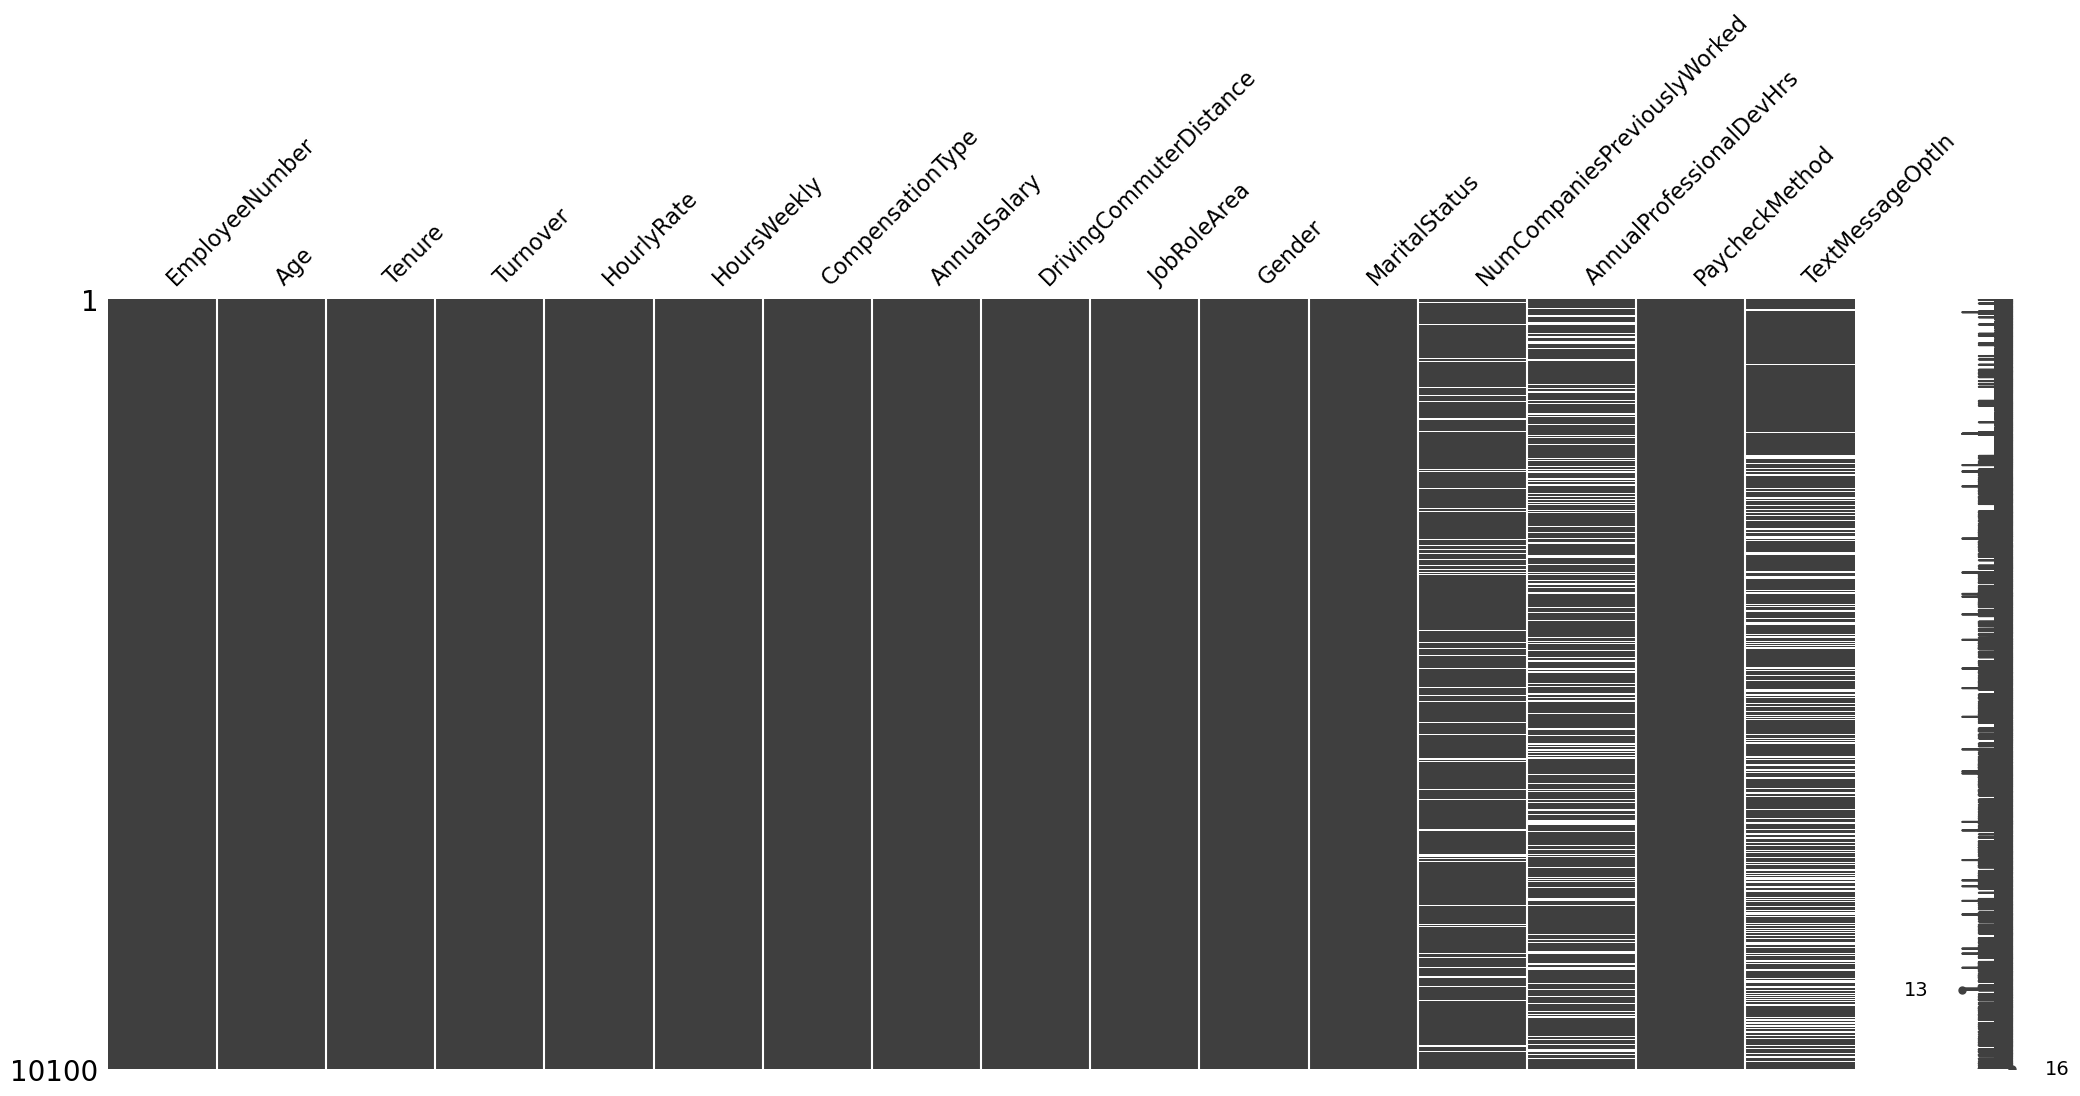

In [63]:
# First Visualize Null Values to identify fields impacted
msno.matrix(Turnover)

# Null Values identified in fields: NumCompaniesPreviouslyWorked, AnnualProfessionalDevHrs, TextMessageOptIn

In [64]:
# Replacing Null Values
"""Nan should be No"""
Turnover['TextMessageOptIn'].replace(np.nan,'No',inplace=True)

"""Nan should be 0.0"""
Turnover['NumCompaniesPreviouslyWorked'].replace(np.nan,0.0,inplace=True)

"""Impute Null Values in AnnualProfessionalDevHrs based off the average for JobRoleArea"""
mean_prodevhrs = Turnover.groupby('JobRoleArea')['AnnualProfessionalDevHrs'].mean()

def fill_with_role_avg(row):
    if pd.isnull(row['AnnualProfessionalDevHrs']):
        return mean_prodevhrs[row['JobRoleArea']]
    else:
        return row['AnnualProfessionalDevHrs']

Turnover['AnnualProfessionalDevHrs'] = Turnover.apply(fill_with_role_avg,axis=1)


<Axes: >

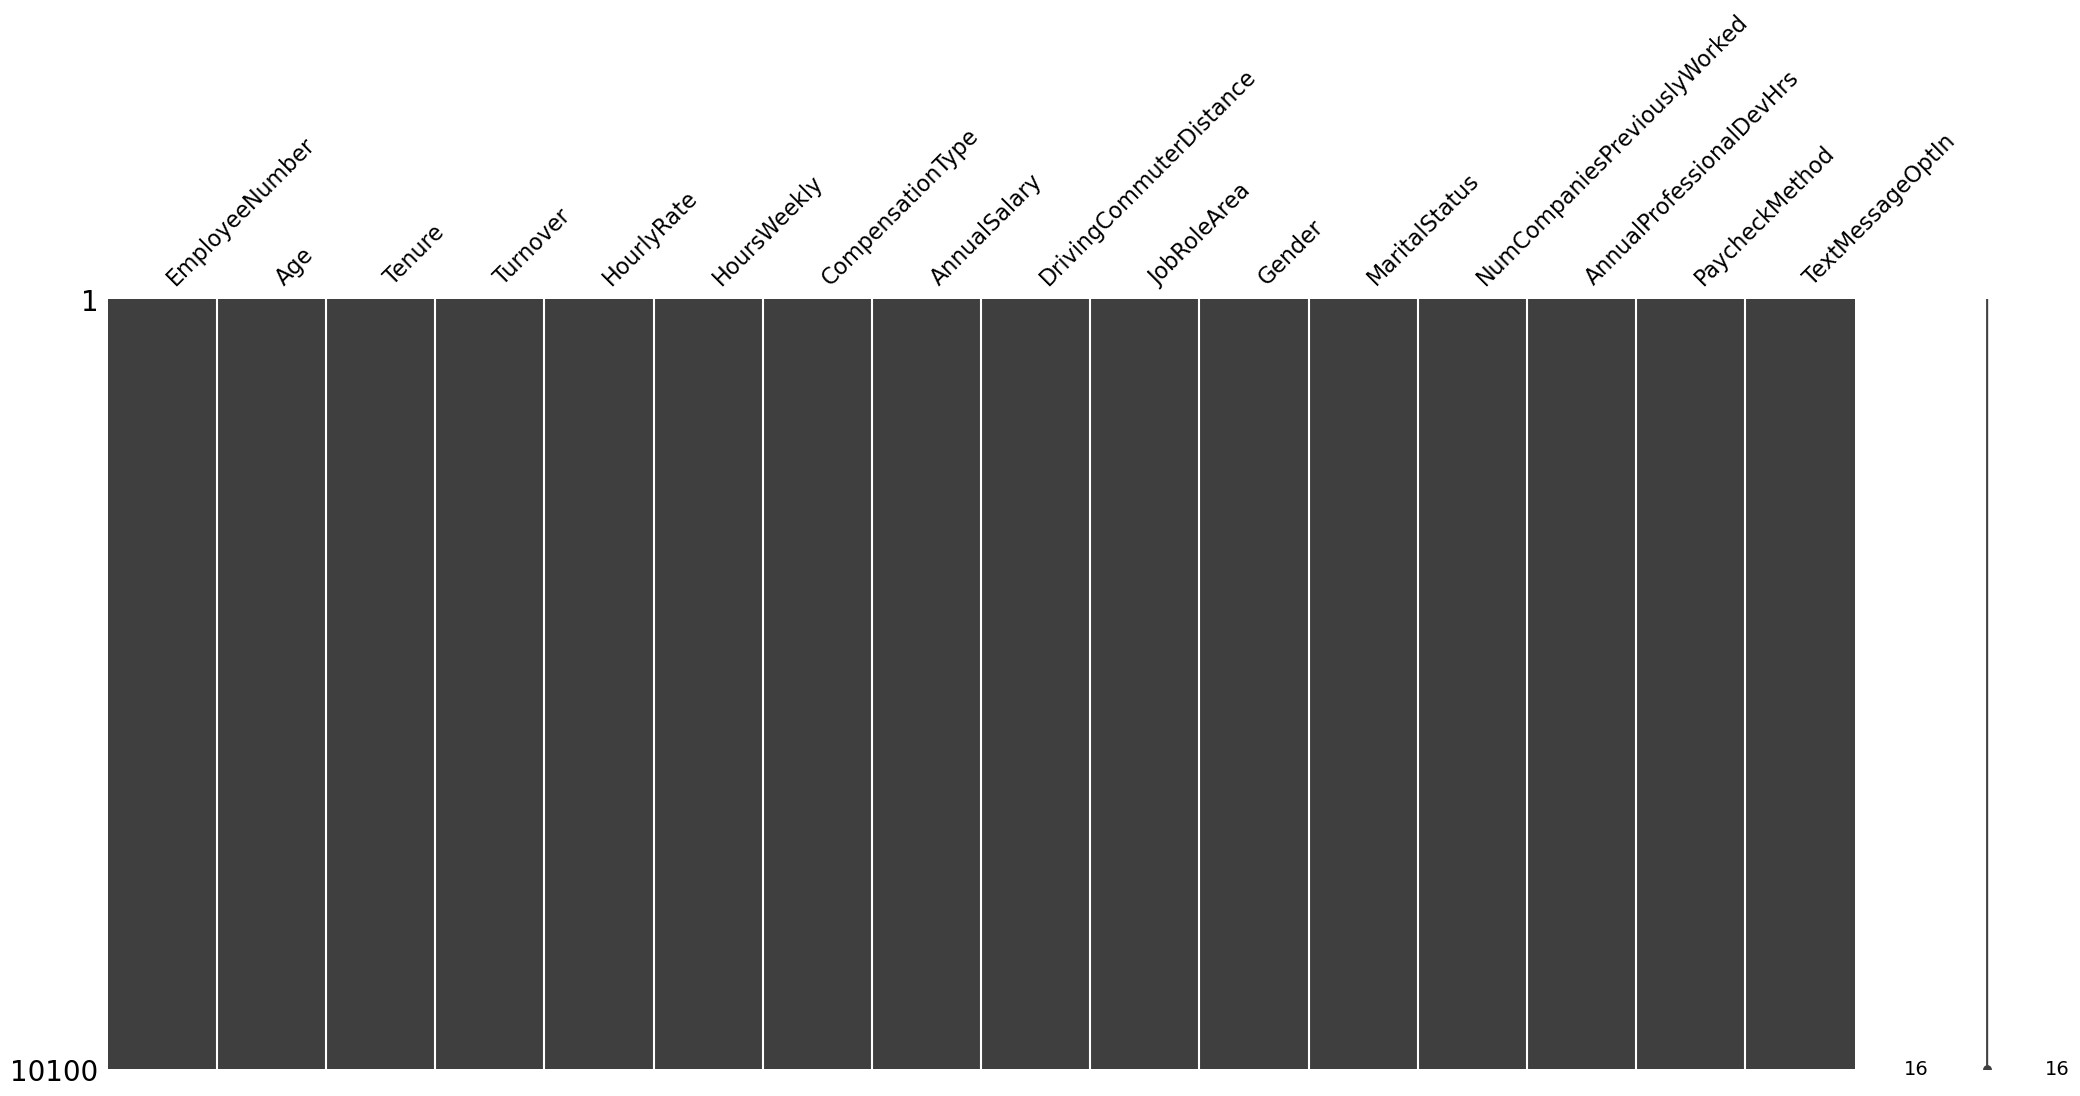

In [65]:
# Re-assess Visual for Null Values
msno.matrix(Turnover)

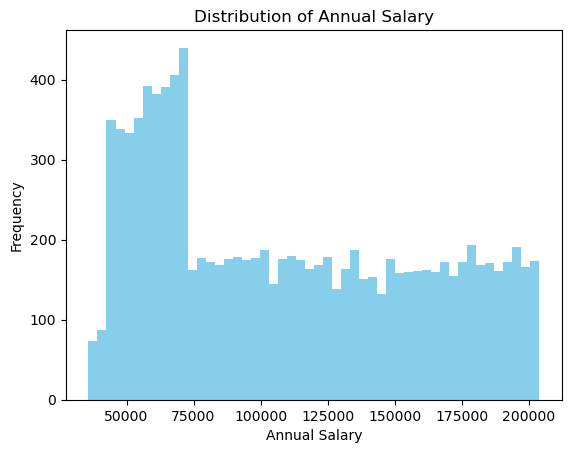

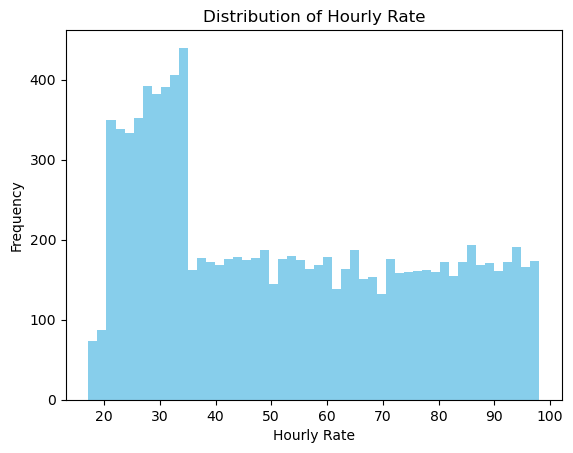

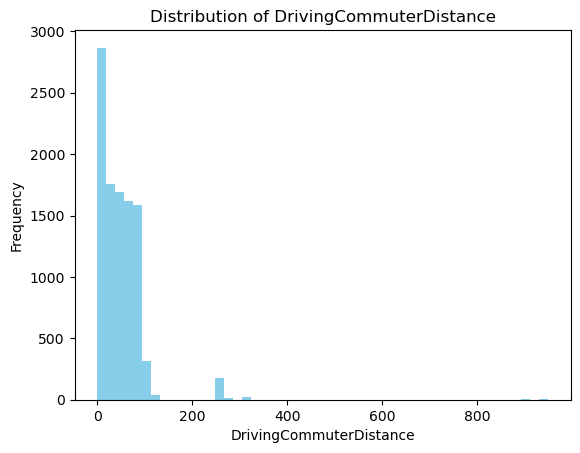

In [66]:
# First Visually Assess Numeric Fields for distribution
"""Assess Distribution in the Annual Salary"""
plt.hist(Turnover['AnnualSalary'], bins=50, color='skyblue')
plt.title('Distribution of Annual Salary')
plt.xlabel('Annual Salary')
plt.ylabel('Frequency')
plt.show()

"""Assess Distribution in the Hourly Rate"""
plt.hist(Turnover['HourlyRate'], bins=50, color='skyblue')
plt.title('Distribution of Hourly Rate')
plt.xlabel('Hourly Rate')
plt.ylabel('Frequency')
plt.show()


"""Assess Distribution in the Commuter Distance"""
plt.hist(Turnover['DrivingCommuterDistance'], bins=50, color='skyblue')
plt.title('Distribution of DrivingCommuterDistance')
plt.xlabel('DrivingCommuterDistance')
plt.ylabel('Frequency')
plt.show()
# Visually, you can see in the plot that DrivingCommuterDistance has values between 200 and 300 

In [67]:
# Second, we'll use the IQR method to identify outliers in the fields: AnnualSalary, HourlyRate, DrivingCommuterDistance

"""Assess outliers in annual salary"""
q1 = np.percentile(Turnover['AnnualSalary'],25)
q3 = np.percentile(Turnover['AnnualSalary'],75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
salary_outliers = Turnover.loc[(Turnover['AnnualSalary'] < lower_bound) | (Turnover['AnnualSalary'] > upper_bound)]

salary_outliers.sort_values(by='AnnualSalary')
print(f"Outliers in Salary: {len(salary_outliers)}")

"""Assess outliers in Hourly Rate"""
q1 = np.percentile(Turnover['HourlyRate'],25)
q3 = np.percentile(Turnover['HourlyRate'],75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
HourlyRate_outliers = Turnover.loc[(Turnover['HourlyRate'] < lower_bound) | (Turnover['HourlyRate'] > upper_bound)]

HourlyRate_outliers.sort_values(by='HourlyRate')
print(f"Outliers in Hourly Rate: {len(HourlyRate_outliers)}")


"""Assess outliers in Hourly Rate"""
q1 = np.percentile(Turnover['DrivingCommuterDistance'],25)
q3 = np.percentile(Turnover['DrivingCommuterDistance'],75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
CommuteDist_outliers = Turnover.loc[(Turnover['DrivingCommuterDistance'] < lower_bound) | (Turnover['DrivingCommuterDistance'] > upper_bound)]

CommuteDist_outliers.sort_values(by='DrivingCommuterDistance')
print(f"Outliers in Commuting Distance: {len(CommuteDist_outliers)}")
# 222 Outliers identified in the Commuting Distance Field

# Impute Outliers
"""Driving Commuter Distance Outliers Imputed to the column mean using np.mean() """
Turnover.loc[(Turnover['DrivingCommuterDistance'] < lower_bound) | (Turnover['DrivingCommuterDistance'] > upper_bound),'DrivingCommuterDistance'] = np.mean(Turnover['DrivingCommuterDistance'])

"""Rounding float values to two decimals"""
Turnover['DrivingCommuterDistance'] = Turnover['DrivingCommuterDistance'].round(2)
Turnover['AnnualSalary'] = Turnover['AnnualSalary'].round(2)
Turnover['HourlyRate'] = Turnover['HourlyRate'].round(2)
Turnover['AnnualProfessionalDevHrs'] = Turnover['AnnualProfessionalDevHrs'].round(2)

Outliers in Salary: 0
Outliers in Hourly Rate: 0
Outliers in Commuting Distance: 222


In [68]:
Turnover.to_csv('./Cleaned_Employee_Turnover_Dataset.csv',index=None)